In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import seaborn as sns

In [4]:
#charger un csv
df = pd.read_csv('./table.csv')
df.head()

,Attempter,Time,Mental demand,Physical demand,Temporal demand,Performance,Effort,Frustration,Type,Rank
0,1,0:03:10,6,1,5,2,1,3,ray,2
1,1,0:02:10,1,1,2,7,2,1,direct,1
2,2,0:01:30,2,1,1,7,1,4,ray,1
3,2,0:01:30,2,2,2,7,3,5,direct,1
4,3,0:03:40,2,2,4,5,4,6,direct,2


/tmp/ipykernel_32920/1333460403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Type", y=col, ax=ax,
/tmp/ipykernel_32920/1333460403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Type", y=col, ax=ax,
/tmp/ipykernel_32920/1333460403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Type", y=col, ax=ax,
/tmp/ipykernel_32920/1333460403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fals

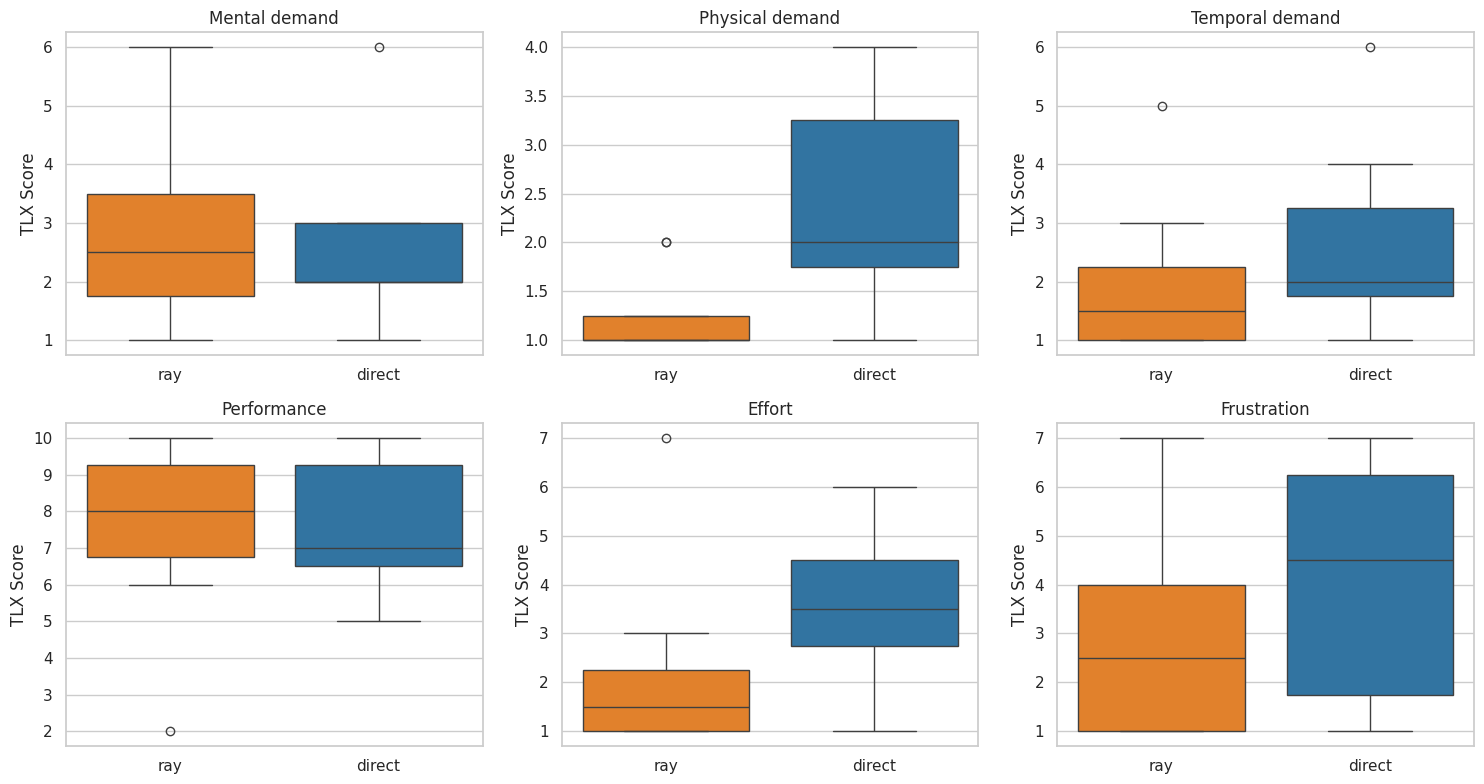

<Figure size 640x480 with 0 Axes>

In [9]:
sns.set(style="whitegrid")

tlx_cols = ["Mental demand", "Physical demand", "Temporal demand", 
            "Performance", "Effort", "Frustration"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), tlx_cols):
    sns.boxplot(data=df, x="Type", y=col, ax=ax,
                palette={"direct": "#1f77b4", "ray": "#ff7f0e"})
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("TLX Score")

plt.tight_layout()
plt.show()
plt.savefig("tlx_boxplots.png")



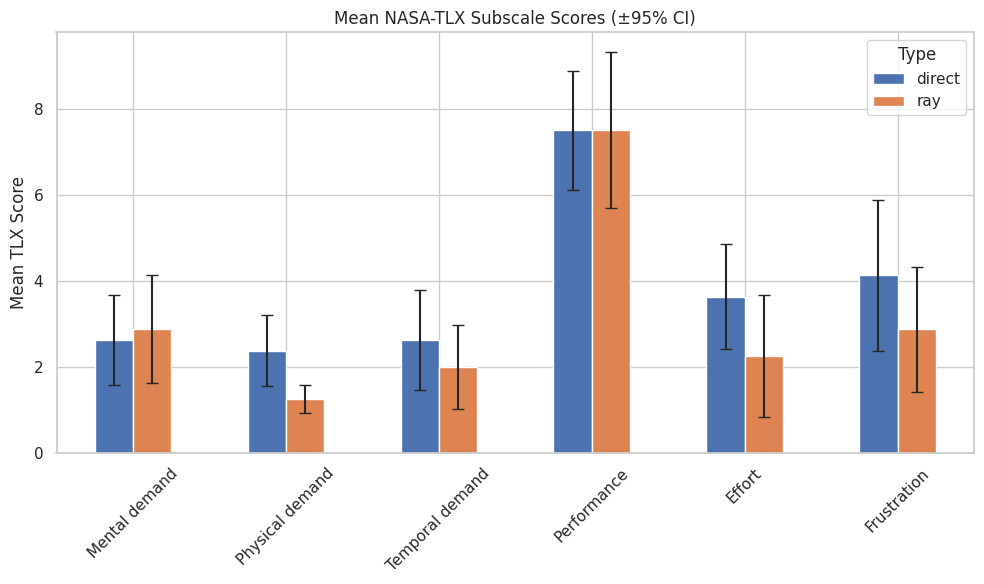

In [11]:
means = df.groupby("Type")[tlx_cols].mean().T
errors = df.groupby("Type")[tlx_cols].sem().T  # Standard error

fig, ax = plt.subplots(figsize=(10, 6))

means.plot(kind="bar", yerr=errors*1.96, ax=ax, capsize=4)
ax.set_ylabel("Mean TLX Score")
ax.set_title("Mean NASA-TLX Subscale Scores (±95% CI)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
print("Wilcoxon Signed-Rank Test Results:\n")

# If you have a participant ID, pivot first:
# df_pivot = df.pivot(index="Participant", columns="Condition", values=col)

for col in tlx_cols:
    direct_vals = df[df["Type"]=="direct"][col].values
    ray_vals    = df[df["Type"]=="ray"][col].values
    
    stat, p = wilcoxon(direct_vals, ray_vals)
    print(f"{col:15s}  W={stat:.3f}   p={p:.4f}")


Wilcoxon Signed-Rank Test Results:

Mental demand    W=10.000   p=0.9161
Physical demand  W=0.000   p=0.0244
Temporal demand  W=4.000   p=0.3430
Performance      W=10.000   p=0.9163
Effort           W=6.500   p=0.2025
Frustration      W=6.000   p=0.3401


/home/raclax/miniconda3/envs/praat/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/raclax/miniconda3/envs/praat/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
